# Week 7 — Filtering a Signal: the z-Domain, FIR Design, and Honest Peaks

**Flow:** difference equation → FIR → frequency response → z^-1 → H(z) → zeros → feedback → poles → stability → design → window → validate → LMS → resolution → zero padding → honest peak.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

## Peak finding

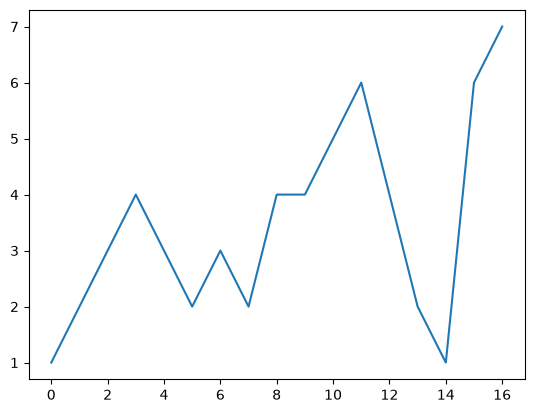

In [2]:
x = np.array([1,2,3,4,3,2,3,2,4,4,5,6,4,2,1,6,7])
t = np.arange(len(x))
plt.plot(t, x)
plt.show()

[ 3  6 11]


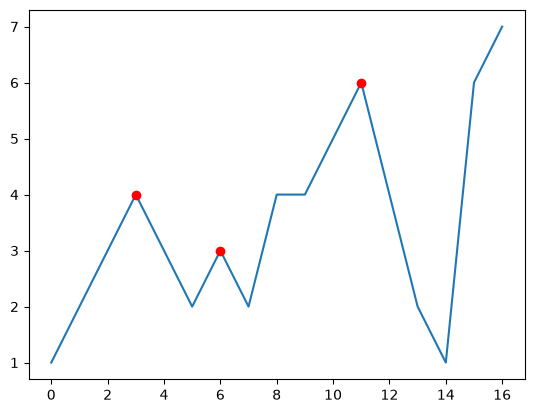

In [3]:
#thres add another condition that our peak have to be > or sth of this point
def find_peak(x, thres=0):
    peak_index = []
    for i in range(1, len(x)-1):
        l = x[i-1]
        m = x[i]
        r = x[i+1]
        if m>l and m>r and x[i]>thres:
            peak_index.append(i)
    return peak_index
# peak = find_peak(x)
# print(peak)

from scipy import signal
peak = signal.find_peaks(x)[0]
print(peak)


plt.plot(t, x)
plt.plot(t[peak], x[peak], 'or')
plt.show()

[3.47499807e-16 3.06646735e-16 4.59053774e-16 1.00000000e+00
 6.51102576e-16 2.00000000e+00 2.50621399e-16 2.64747608e-16
 6.00000000e-01 2.02602125e-16 5.79370373e-16 1.07386245e-15
 1.69371145e-15 1.59759288e-15 6.63194030e-16 6.18195571e-16
 6.31888072e-16 2.46779379e-16 7.04302046e-16 7.02436341e-16
 4.40663029e-16 7.93477976e-16 9.33969506e-16 4.16836447e-16
 2.94837097e-16 2.19260971e-16 2.93974661e-16 3.21969392e-16
 3.85478313e-16 1.10411540e-15 8.13173090e-16 2.02254530e-16
 4.39776650e-16 2.54045392e-16 2.48777872e-16 1.72238682e-16
 8.23818200e-16 5.15418136e-16 7.37190079e-16 4.19597841e-16
 4.61152085e-16 2.30824584e-16 7.38886180e-17 8.09770527e-17
 2.38434855e-16 4.24438172e-16 1.17848770e-15 8.17745913e-16
 2.58465860e-16 1.49500244e-16]


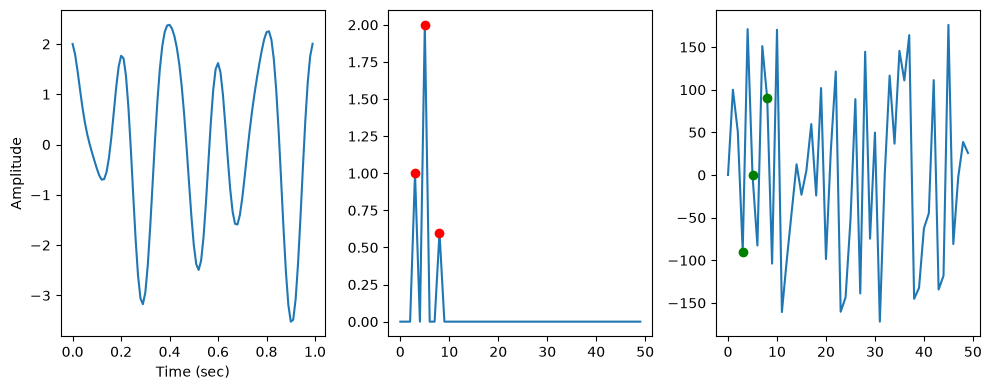

In [4]:
# Find peak on magnitude
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(3, t, A=1.0, p=0) + generate_sine(5, t, A=2.0, p=np.pi/2) + generate_sine(8, t, A=0.6, p=np.pi)
# Raw signal
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(t, x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)")

# Spectrum
X = np.fft.fft(x)
N = len(X)
X  = X[:N//2]
mag = 2*np.abs(X) / N
mag[0] = mag[0]/2
mag[-1] = mag[-1]/2
freq = np.arange(len(mag)) * fs/N

plt.subplot(1, 3, 2)
plt.plot(freq, mag)
print(mag)
from scipy import signal
peak = signal.find_peaks(mag, 0.1)[0]
plt.plot(freq[peak], mag[peak], 'or')

# Phase
phase = np.angle(X, deg = True)
plt.subplot(1, 3, 3)
plt.plot(freq, phase)
# peak = signal.find_peaks(phase)[0]
plt.plot(freq[peak], phase[peak], 'og')

plt.tight_layout()
plt.show()


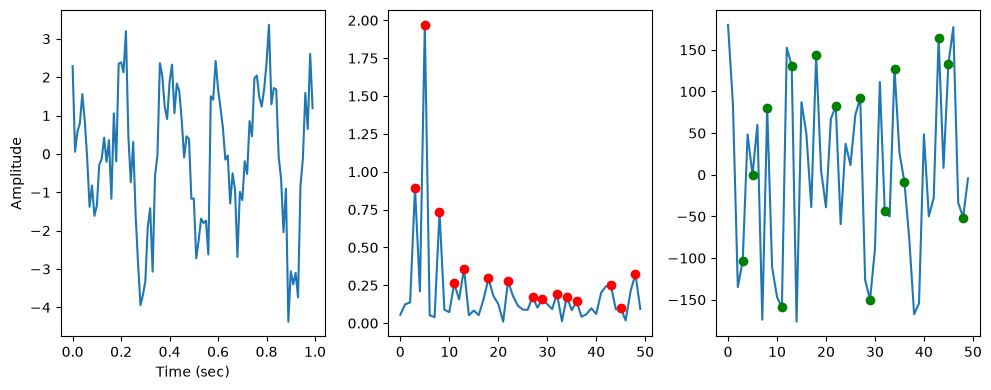

In [5]:
# Add some noise
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(3, t, A=1.0, p=0) + generate_sine(5, t, A=2.0, p=np.pi/2) + generate_sine(8, t, A=0.6, p=np.pi)
# Noise
noise = np.random.normal(0, 0.8, len(x))
x += noise
# Raw signal
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(t, x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)")

# Spectrum
X = np.fft.fft(x)
N = len(X)
X  = X[:N//2]
mag = 2*np.abs(X) / N
mag[0] = mag[0]/2
mag[-1] = mag[-1]/2
freq = np.arange(len(mag)) * fs/N

plt.subplot(1, 3, 2)
plt.plot(freq, mag)
from scipy import signal
peak = signal.find_peaks(mag, 0.1)[0]
plt.plot(freq[peak], mag[peak], 'or')

# Phase
phase = np.angle(X, deg = True)
plt.subplot(1, 3, 3)
plt.plot(freq, phase)
# peak = signal.find_peaks(phase)[0]
plt.plot(freq[peak], phase[peak], 'og')

plt.tight_layout()
plt.show()



[0.00136447 0.00245373 0.00449006 0.00527933 0.00566181 0.00567711
 0.00597479 0.00633466 0.00691181 0.00707634 0.0072761  0.00735585
 0.00795793 0.00816594 0.00844013 0.00867847 0.00873446 0.00877264
 0.00924289 0.00989846 0.01155344 0.01177458 0.01327669 0.0137972
 0.01381497 0.01554013 0.01726441 0.01779805 0.02087851 0.0210566
 0.02211917 0.02432097 0.02519851 0.02568999 0.02651712 0.03113417
 0.03369308 0.03625251 0.04156615 0.04268855 0.04403653 0.04960268
 0.05934762 0.08552119 0.13078345 0.13444971 0.1762616  0.24425329
 0.81048304 1.33316383]


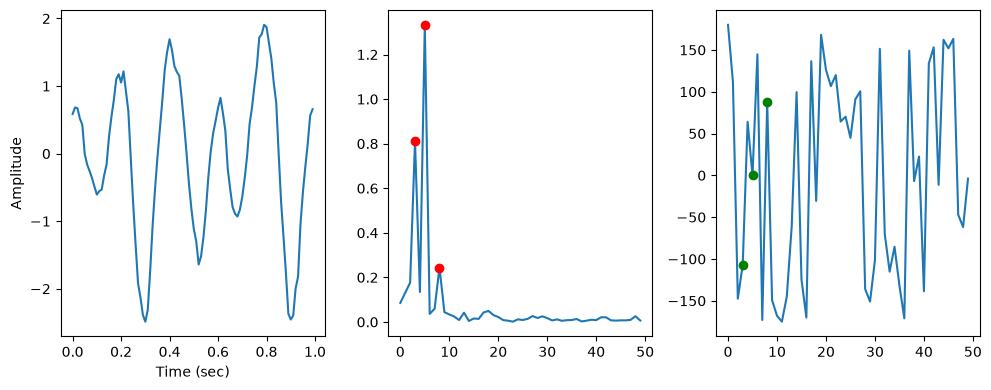

In [13]:
# Smooth with moving avg
def moving_average(x, w):
    kernel = np.ones(w)/w
    y = np.convolve(x, kernel, mode='same')
    return y

smooth_x = moving_average(x, 9) # Try change window size

# Raw signal
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.plot(t, smooth_x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)")

# Spectrum
X = np.fft.fft(smooth_x)
N = len(X)
X  = X[:N//2]
mag = 2*np.abs(X) / N
mag[0] = mag[0]/2
mag[-1] = mag[-1]/2
m = mag.copy()
m.sort()
print(m)
freq = np.arange(len(mag)) * fs/N

plt.subplot(1, 3, 2)
plt.plot(freq, mag)
from scipy import signal
peak = signal.find_peaks(mag, 0.1)[0]

plt.plot(freq[peak], mag[peak], 'or')

# Phase
phase = np.angle(X, deg = True)
plt.subplot(1, 3, 3)
plt.plot(freq, phase)
# peak = signal.find_peaks(phase)[0]
plt.plot(freq[peak], phase[peak], 'og')

plt.tight_layout()
plt.show()




## Frequency response

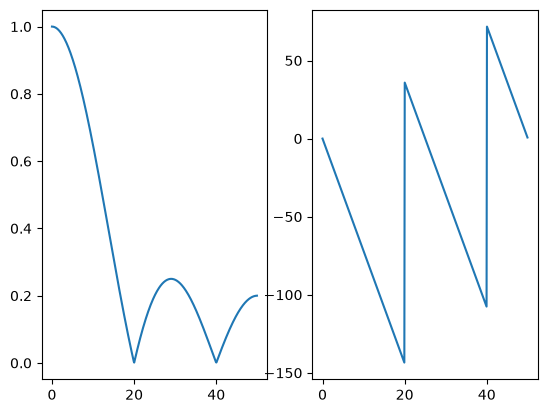

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 100

b = [1/5, 1/5, 1/5, 1/5, 1/5]
a = [1.0]
#omega or w : frequency, h: complex number
w, h = signal.freqz(b, a, fs=fs)
mag = np.abs(h)
phase = np.angle(h, deg = True)
plt.subplot(1, 2, 1)
plt.plot(w, mag)

plt.subplot(1, 2, 2)
plt.plot(w, phase)


[33.10546875 33.203125   33.30078125 33.3984375  33.49609375 33.59375   ]


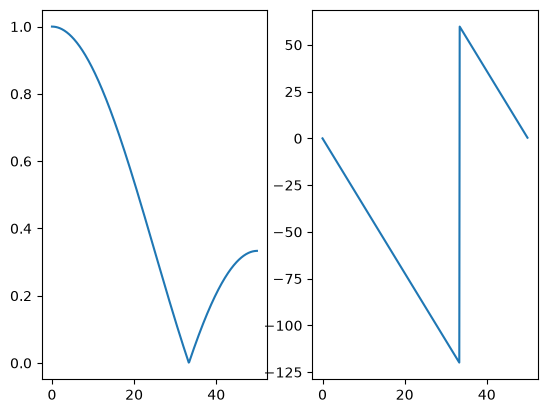

In [8]:
fs = 100

b = [1/3, 1/3, 1/3]
a = [1.0]
#omega or w : frequency, h: complex number
w, h = signal.freqz(b, a, fs=fs)

mag = np.abs(h)
phase = np.angle(h, deg = True)
plt.subplot(1, 2, 1)
plt.plot(w, mag)

plt.subplot(1, 2, 2)
plt.plot(w, phase)

print(w[mag<0.01])

In [ ]:
# Ex2 แสดง frequency response ของ function3-6
fs = 100

b = [ ???? ]
a = [1.0]



## ทดลองกับฟังก์ชันจริง

In [1]:
def func1(x):
    return 2*x
def func2(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1:] = x[1:] - x[:-1] # 1: from the first to last,  :-1 from start to the last-1
    # y we take each from value to calculate by slide through list and minus each one
    return y
def func3(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1:] = x[1:] + x[:-1] # 1: from the first to last,  :-1 from start to the last-1
    # y we take each from value to calculate by slide through list and minus each one
    return y
def func4(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1:] = x[1:]*2 + x[:-1]*3
    return y
def func5(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1] = x[1]
    y[2:] = 0.5*x[2:] + 0.8*x[1:-1] -0.5*x[:-2]
    return y
def func6(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1] = x[1]
    y[2:] = x[2:] + 0.8*x[1:-1] +x[:-2]
    return y
def func7(x):
    y = np.zeros(len(x))
    y[0] = x[0]
    y[1] = x[1]
    y[2:] = 1/3*(x[2:] + x[1:-1] +x[:-2])
    return y

fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(10, t, A=1.0, p=0) + generate_sine(30, t, A=1, p=0) + generate_sine(48, t, A=1, p=0)

# Raw signal
plt.figure(figsize=(12,5))
plt.subplot(2, 3, 1)
plt.plot(t, x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)"); plt.title("Raw")

N=len(x)
X = np.fft.fft(x)
X = X[:N//2]
mag = 2*np.abs(X)/N
freq = np.arange( len(mag) ) * fs / N 
plt.subplot(2, 3, 2)
plt.plot(freq, mag)
peak = find_peak(mag, 0.1)
plt.plot(freq[peak], mag[peak], 'or')
plt.ylabel("Amplitude"); plt.xlabel("Frequency (hz)")

phase = np.angle(X, deg=True)
plt.subplot(2, 3, 3)
plt.scatter(freq, phase, s=2, color='gray')
plt.scatter(freq[peak], phase[peak], s=20, color='red')
plt.ylabel("Phase"); plt.xlabel("Frequency (hz)")

# apply function
y = func5(x)

plt.subplot(2, 3, 4)
plt.plot(t, y)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)"); plt.title("Result")

N=len(y)
X = np.fft.fft(y)
X = X[:N//2]
mag = 2*np.abs(X)/N
freq = np.arange( len(mag) ) * fs / N
plt.subplot(2, 3, 5)
plt.plot(freq, mag)
peak = find_peak(mag, 0.1)
plt.plot(freq[peak], mag[peak], 'or')
plt.ylabel("Amplitude"); plt.xlabel("Frequency (hz)")

phase = np.angle(X, deg=True)
plt.subplot(2, 3, 6)
plt.scatter(freq, phase, s=2, color='gray')
plt.scatter(freq[peak], phase[peak], s=20, color='red')
plt.ylabel("Phase"); plt.xlabel("Frequency (hz)")

plt.tight_layout()
plt.savefig("image/670710258.png")
n

NameError: name 'time_axis' is not defined

In [ ]:
def func2(x):
    y = np.zeros(len(x))
    y[0] = x[0]         
    y[1:] = x[1:] - x[:-1]
    return y

fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(10, t, A=1.0, p=0) + generate_sine(30, t, A=1, p=0) + generate_sine(48, t, A=1, p=0)

# Raw signal
plt.figure(figsize=(10,4))
plt.subplot(2, 3, 1)
plt.plot(t, x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)"); plt.title("Raw")

N=len(x)
X = np.fft.fft(x)
X = X[:N//2]
mag = 2*np.abs(X)/N
freq = np.arange( len(mag) ) * fs / N 
plt.subplot(2, 3, 2)
plt.plot(freq, mag)
peak = find_peak(mag, 0.1)
plt.plot(freq[peak], mag[peak], 'or')
plt.ylabel("Amplitude"); plt.xlabel("Frequency (hz)")

phase = np.angle(X, deg=True)
plt.subplot(2, 3, 3)
plt.scatter(freq, phase, s=2, color='gray')
plt.scatter(freq[peak], phase[peak], s=20, color='red')
plt.ylabel("Phase"); plt.xlabel("Frequency (hz)")

# apply function
y = func2(x)


????

In [ ]:
# Ex3 ทดสอบ func3-7 กับสัญญาณ 10Hz, 30Hz, 50Hz
def func3(x):
    
    return y



In [ ]:
def func4(x):
    
    return y

In [ ]:
def func5(x):
    
    return y

In [ ]:
def func6(x):
    
    return y

In [ ]:
def func7(x):
    
    return y

## FIR design

In [ ]:
b = signal.firwin(numtaps=3, cutoff=10, fs=100)
a = [1.0]
print(b)

In [ ]:
fs = 100
w, h = signal.freqz(b, a, fs=fs)

???

In [ ]:
fs = 100
b = signal.firwin(numtaps=20, cutoff=20, fs=fs)
a = [1.0]
print(b)

???

In [ ]:
# Plot magnitude in dB
fs = 100
b = signal.firwin(numtaps=20, cutoff=20, fs=fs)
a = [1.0]

???


In [ ]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(10, t, A=1.0, p=0) + generate_sine(30, t, A=1, p=0) + generate_sine(48, t, A=1, p=0)

# Raw signal
plt.figure(figsize=(10,4))
plt.subplot(2, 3, 1)
plt.plot(t, x)
plt.ylabel("Amplitude"); plt.xlabel("Time (sec)"); plt.title("Raw")

N=len(x)
X = np.fft.fft(x)
X = X[:N//2]
mag = 2*np.abs(X)/N
freq = np.arange( len(mag) ) * fs / N 
plt.subplot(2, 3, 2)
plt.plot(freq, mag)
peak = find_peak(mag, 0.2)
plt.plot(freq[peak], mag[peak], 'or')
plt.ylabel("Amplitude"); plt.xlabel("Frequency (hz)")

phase = np.angle(X, deg=True)
plt.subplot(2, 3, 3)
plt.scatter(freq, phase, s=2, color='gray')
plt.scatter(freq[peak], phase[peak], s=20, color='red')
plt.ylabel("Phase"); plt.xlabel("Frequency (hz)")

# apply function
b = signal.firwin(numtaps=20, cutoff=20, fs=fs)
a = [1.0]
y = signal.lfilter(b, a, x)

???

In [ ]:
# Ex7 สร้างสัญญาณ 3 ความถี่ ที่ A และ phase ต่างกัน
# f1 ความถี่ต่ำสุด, f2 ความถี่กลาง, f3 ความถี่สูงสุด แต่ต้องไม่เกิน Nyquist
# 7.1 ออกแบบตัวกรอง low pass ที่เก็บเฉพาะ ความถี่ f1 (cutoff freq = f1)
# เขียนพารามิเตอร์ firwin ในใบงาน
# ทำ subplot แสดง 
# 1. frequency response ทั้่ง magnitude และ phase
# 2. สัญญาณต้นฉบับ, spectrum, และ phase พร้อมเน้นจุด peak ของสัญญาณ
# 3. สัญญาณที่ผ่านตัวกรอง ด้วยคำสั่ง lfilter, spectrum และ phase พร้อมเน้นจุด peak ของสัญญาณ
# subplot (3,3,x)
# [magnitude response] [phase response]
# [Raw signal]         [Spectrum]       [Phase]
# [Filtered signal]    [Spectrum]       [Phase]



In [ ]:
# 7.2 ออกแบบตัวกรอง high pass ที่เก็บเฉพาะ f3



In [ ]:
# 7.3 ออกแบบตัวกรอง band pass ที่ปล่อยเฉพาะความถี่ f2 ตัดช่วง f1, f3



In [ ]:
# 7.3 ออกแบบตัวกรอง band stop ที่ตัดเฉพาะความถี่ f2 ออก เก็บ f1, f3



## Window: frequency response

In [ ]:
b = signal.windows.hann(N)
a = [1.0]

w, h = signal.freqz(b, a, fs=fs)

mag = np.abs(h)
mag /= np.max(mag)
mag = 20*np.log10(mag)
phase = np.angle(h, deg=True)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1); plt.plot(w, mag)
plt.xlabel("frequency (Hz)"); plt.ylabel("Magnitude (dB)")
plt.title("Magnitude")

plt.subplot(1, 2, 2); plt.plot(w, phase)
plt.xlabel("frequency (Hz)"); plt.ylabel("Phase (degree)")
plt.title("Phase")

plt.tight_layout()
plt.show()

In [ ]:
mag_zoom = mag[:40]
w_zoom = w[:40]
peaks, _ = signal.find_peaks(mag_zoom)
first_side_lobe = peaks[0]

plt.plot(w_zoom, mag_zoom)
plt.plot(w_zoom[first_side_lobe], mag_zoom[first_side_lobe], 'or')
plt.xlabel("frequency (Hz)"); plt.ylabel("Magnitude (dB)")
plt.title(f"Magnitude: Side lobe {w_zoom[first_side_lobe]:.2f} Hz/ {mag_zoom[first_side_lobe]:.2f}")
plt.show()

In [ ]:
# Ex 8.1 แสดง frequency response เฉพาะ magnitude ของหน้าต่าง Rectangle, Hanning, Hamming, Flat-Top ในกราฟเดียวกัน


In [ ]:
# Ex 8.2 zoom ช่วงความถี่ < 10Hz ของ 8.1
# หน้าต่างใด มี main lobe กว้างสุด
# หน้าต่างใด มีความต่างระหว่าง main lobe และ side lobe สูงสุด

